# 🚗 Driver Behavior Anomaly Detection
## Notebook 04 — Class Balancing & Normalization (Steps 5 & 6)

### Step 5: Handle Class Imbalance with SMOTE
Aggressive and slow events are **rarer** than normal driving.  
If we train on imbalanced data, the model will just always predict "NORMAL".

**Solution:** SMOTE — Synthetic Minority Oversampling Technique  
Creates *new synthetic samples* by interpolating between existing minority class examples.  
*(Applied on training set only — never touch validation/test data)*

### Step 6: Normalize Features
Acceleration (m/s²) and Gyroscope (rad/s) are on **different scales**.  
StandardScaler → zero mean, unit variance per feature.  
*(Fit on training set only — apply same transform to val/test)*

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from imblearn.over_sampling  import SMOTE

OUTPUT_DIR  = "outputs"
CLASS_NAMES = ["NORMAL", "AGGRESSIVE", "SLOW"]
RANDOM_SEED = 42
TEST_SPLIT  = 0.15
VAL_SPLIT   = 0.15

# Load windowed data from Notebook 03
X = np.load(f"{OUTPUT_DIR}/X_windows.npy")
y = np.load(f"{OUTPUT_DIR}/y_windows.npy")

print(f"✅ Loaded:  X {X.shape}   y {y.shape}")
print(f"\nClass counts before split:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {np.sum(y==i)}")

✅ Loaded:  X (122, 50, 11)   y (122,)

Class counts before split:
  NORMAL: 40
  AGGRESSIVE: 32
  SLOW: 50


### Train / Validation / Test Split

In [2]:
# Step 1: carve out test set (15%) — stratified so all classes are represented
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=RANDOM_SEED
)

# Step 2: carve out validation set (15% of original) from remainder
val_fraction = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction, stratify=y_temp, random_state=RANDOM_SEED
)

print("Data splits (before SMOTE):")
print(f"  Train : {X_train.shape}   → {len(X_train)} windows")
print(f"  Val   : {X_val.shape}   → {len(X_val)} windows")
print(f"  Test  : {X_test.shape}   → {len(X_test)} windows")
print(f"\n  Test will be UNTOUCHED until final evaluation")

Data splits (before SMOTE):
  Train : (84, 50, 11)   → 84 windows
  Val   : (19, 50, 11)   → 19 windows
  Test  : (19, 50, 11)   → 19 windows

  Test will be UNTOUCHED until final evaluation


### Step 5 — Apply SMOTE (on training set only)

In [3]:
# SMOTE needs 2D input → flatten windows, then restore shape after
n_windows, window_size, n_features = X_train.shape
X_train_flat = X_train.reshape(n_windows, window_size * n_features)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

# k_neighbors must be < smallest class size
k = min(5, min(np.bincount(y_train)) - 1)
sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=k)
X_train_flat_res, y_train_res = sm.fit_resample(X_train_flat, y_train)

# Restore 3D shape
X_train_res = X_train_flat_res.reshape(-1, window_size, n_features)

print("After  SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))
print(f"\nTraining set size: {len(X_train)} → {len(X_train_res)} windows")

Before SMOTE: {np.int32(0): np.int64(28), np.int32(1): np.int64(22), np.int32(2): np.int64(34)}
After  SMOTE: {np.int32(0): np.int64(34), np.int32(1): np.int64(34), np.int32(2): np.int64(34)}

Training set size: 84 → 102 windows


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

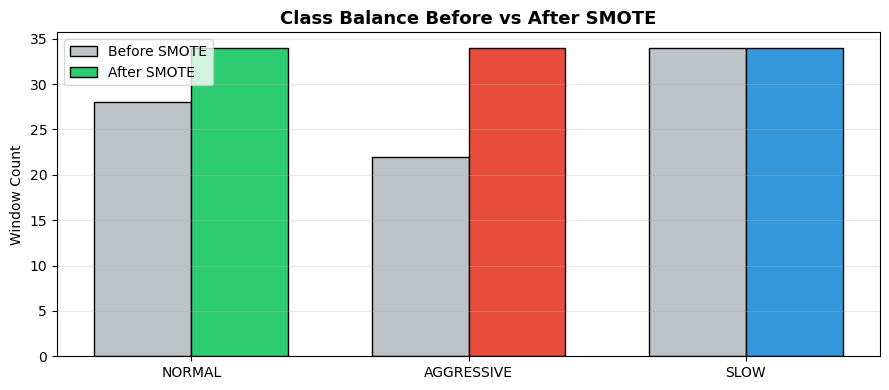

In [4]:
# Visualise before vs after SMOTE
counts_before = [np.sum(y_train == i) for i in range(len(CLASS_NAMES))]
counts_after  = [np.sum(y_train_res == i) for i in range(len(CLASS_NAMES))]

x   = np.arange(len(CLASS_NAMES))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(x - w/2, counts_before, w, label='Before SMOTE', color='#bdc3c7', edgecolor='black')
ax.bar(x + w/2, counts_after,  w, label='After SMOTE',
       color=["#2ecc71","#e74c3c","#3498db"], edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title("Class Balance Before vs After SMOTE", fontsize=13, fontweight='bold')
ax.set_ylabel("Window Count"); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_smote.png", dpi=150, bbox_inches='tight')
plt.show()

### Step 6 — Normalize (StandardScaler)

In [5]:
# Fit scaler on training data only → transform all sets with the SAME scaler
n_tr, T, F = X_train_res.shape

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res.reshape(-1, F)).reshape(n_tr, T, F)
X_val_scaled   = scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape)

print("✅ Normalization complete")
print(f"\nScaler means  (first 4 features): {scaler.mean_[:4].round(4)}")
print(f"Scaler stdevs (first 4 features): {scaler.scale_[:4].round(4)}")

print(f"\nFinal dataset shapes:")
print(f"  X_train : {X_train_scaled.shape}   y_train : {y_train_res.shape}")
print(f"  X_val   : {X_val_scaled.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test_scaled.shape}    y_test  : {y_test.shape}")

✅ Normalization complete

Scaler means  (first 4 features): [ 0.1201 -0.1392  0.0347  0.0018]
Scaler stdevs (first 4 features): [0.9567 0.9072 0.9814 0.0649]

Final dataset shapes:
  X_train : (102, 50, 11)   y_train : (102,)
  X_val   : (19, 50, 11)     y_val   : (19,)
  X_test  : (19, 50, 11)    y_test  : (19,)


### Save splits + scaler

In [6]:
import pickle

np.save(f"{OUTPUT_DIR}/X_train.npy", X_train_scaled)
np.save(f"{OUTPUT_DIR}/X_val.npy",   X_val_scaled)
np.save(f"{OUTPUT_DIR}/X_test.npy",  X_test_scaled)
np.save(f"{OUTPUT_DIR}/y_train.npy", y_train_res)
np.save(f"{OUTPUT_DIR}/y_val.npy",   y_val)
np.save(f"{OUTPUT_DIR}/y_test.npy",  y_test)

with open(f"{OUTPUT_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

print("✅ All splits and scaler saved to outputs/")

✅ All splits and scaler saved to outputs/


### ✅ Balancing & Normalization Complete

**What we did:**
- Split data → **70% train / 15% val / 15% test** (stratified)
- Applied **SMOTE** to training set → balanced all 3 classes equally
- **StandardScaler** fitted on train → applied to val/test (no data leakage)

**Next:** `05_Model_Training.ipynb`